In [1]:
import pandas as pd

data_path = "../data/task_offloading_dataset.csv"
task_data = pd.read_csv(data_path)

task_data.head(), task_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204823 entries, 0 to 204822
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Cell_Identity(CI)    204823 non-null  int64  
 1   Downlink_Traffic     204823 non-null  int64  
 2   LAC                  204823 non-null  int64  
 3   Duration             204823 non-null  int64  
 4   RAT                  204823 non-null  int64  
 5   Uplink_Traffic       204823 non-null  int64  
 6   Latency              204823 non-null  float64
 7   Throughput           204823 non-null  float64
 8   Offloading_Decision  204823 non-null  object 
dtypes: float64(2), int64(6), object(1)
memory usage: 14.1+ MB


(   Cell_Identity(CI)  Downlink_Traffic    LAC  Duration  RAT  Uplink_Traffic  \
 0              11803               464   3288         2    2             585   
 1              20723                 0  43023        15    1             300   
 2              11803               514   3288         1    2             559   
 3               7483               900   3287        82    2             559   
 4              20723              1276  43023      2131    1            2280   
 
        Latency   Throughput Offloading_Decision  
 0     2.000000   524.500000       Mobile Device  
 1    15.000000    20.000000       Mobile Device  
 2     1.000000  1073.000000       Mobile Device  
 3    87.542193    16.666249          Edge Cloud  
 4  2131.000000     1.668700       Mobile Device  ,
 None)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

label_encoder = LabelEncoder()
task_data['Offloading_Decision'] = label_encoder.fit_transform(task_data['Offloading_Decision'])

X = task_data.drop('Offloading_Decision', axis=1)
y = task_data['Offloading_Decision']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((163858, 8), (40965, 8), (163858,), (40965,))

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(124, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=1)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
test_loss, test_accuracy


Matplotlib is building the font cache; this may take a moment.


Epoch 1/50


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4097/4097 ━━━━━━━━━━━━━━━━━━━━ 2s 471us/step - accuracy: 0.7603 - loss: 0.4066 - val_accuracy: 0.9401 - val_loss: 0.1428
Epoch 2/50
4097/4097 ━━━━━━━━━━━━━━━━━━━━ 2s 420us/step - accuracy: 0.9414 - loss: 0.1409 - val_accuracy: 0.9573 - val_loss: 0.0993
Epoch 3/50
4097/4097 ━━━━━━━━━━━━━━━━━━━━ 2s 425us/step - accuracy: 0.9505 - loss: 0.1279 - val_accuracy: 0.9550 - val_loss: 0.0927
Epoch 4/50
4097/4097 ━━━━━━━━━━━━━━━━━━━━ 2s 425us/step - accuracy: 0.9509 - loss: 0.1218 - val_accuracy: 0.9698 - val_loss: 0.1863
Epoch 5/50
4097/4097 ━━━━━━━━━━━━━━━━━━━━ 2s 422us/step - accuracy: 0.9402 - loss: 0.1474 - val_accuracy: 0.9699 - val_loss: 0.0736
Epoch 6/50
4097/4097 ━━━━━━━━━━━━━━━━━━━━ 2s 420us/step - accuracy: 0.9567 - loss: 0.1081 - val_accuracy: 0.9395 - val_loss: 0.1276
Epoch 7/50
4097/4097 ━━━━━━━━━━━━━━━━━━━━ 2s 431us/step - accuracy: 0.9621 - loss: 0.0901 - val_accuracy: 0.9822 - val_loss: 0.0587
Epoch 8/50
4097/4097 ━━━━━━━━━━━━━━━━━━━━ 2s 412us/step - accuracy: 0.9599 - loss: 0.10

(0.058884840458631516, 0.9814475774765015)

In [10]:
import os
original_model_path = "../models/DNN_original.h5"
model.save(original_model_path)
original_model_size = os.path.getsize(original_model_path) / 1024  # Size in KB

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Save the quantized model
tflite_model_path = "../models/DNN_quantized.tflite"
with open(tflite_model_path, "wb") as f:
    f.write(tflite_model)
quantized_model_size = os.path.getsize(tflite_model_path) / 1024  # Size in KB

print(f"Original model size: {original_model_size:.2f} KB")
print(f"Quantized model size: {quantized_model_size:.2f} KB")
print(f"Reduction in size: {original_model_size - quantized_model_size:.2f} KB ({((original_model_size - quantized_model_size) / original_model_size) * 100:.2f}%)")

# Function to evaluate the TensorFlow Lite model
def evaluate_tflite_model(tflite_model_path, X_test, y_test):
    # Load the TFLite model
    interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()

    # Get input and output details
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Perform inference on test data
    predictions = []
    for i in range(len(X_test)):
        input_data = X_test[i:i+1].astype('float32')
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        predictions.append(output[0][0])

    # Convert predictions to binary labels
    predictions = [1 if p > 0.5 else 0 for p in predictions]

    # Calculate accuracy
    accuracy = sum(1 for p, y in zip(predictions, y_test) if p == y) / len(y_test)
    return accuracy

# Evaluate the TensorFlow Lite model on the test set
tflite_accuracy = evaluate_tflite_model(tflite_model_path, X_test, y_test)
print(f"TensorFlow Lite model accuracy: {tflite_accuracy:.4f}")

INFO:tensorflow:Assets written to: /var/folders/6t/np9bk5n10lq97yhftqs2k_640000gp/T/tmpwur14d6u/assets


INFO:tensorflow:Assets written to: /var/folders/6t/np9bk5n10lq97yhftqs2k_640000gp/T/tmpwur14d6u/assets


Saved artifact at '/var/folders/6t/np9bk5n10lq97yhftqs2k_640000gp/T/tmpwur14d6u'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 8), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  6092510352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6092511504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6092509584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6092509008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6092512080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6092509776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6092512464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6092511312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6092511888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6092513616: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1737879775.047014 7879146 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1737879775.047022 7879146 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


Original model size: 179.15 KB
Quantized model size: 20.54 KB
Reduction in size: 158.61 KB (88.54%)
TensorFlow Lite model accuracy: 0.9816


2025-01-26 13:52:55.047109: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/6t/np9bk5n10lq97yhftqs2k_640000gp/T/tmpwur14d6u
2025-01-26 13:52:55.047453: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-01-26 13:52:55.047457: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/6t/np9bk5n10lq97yhftqs2k_640000gp/T/tmpwur14d6u
2025-01-26 13:52:55.050525: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-01-26 13:52:55.068036: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/6t/np9bk5n10lq97yhftqs2k_640000gp/T/tmpwur14d6u
2025-01-26 13:52:55.073394: I tensorflow/cc/saved_model/loader.cc:466] SavedModel load for tags { serve }; Status: success: OK. Took 26285 microseconds.


In [5]:
import numpy as np

example_data = np.array([[11803, 464, 3288, 2, 2, 585, 2, 524.5]])

example_data_scaled = scaler.transform(example_data)

predicted_probability = model.predict(example_data_scaled)

predicted_decision = (predicted_probability > 0.5).astype(int)

# Output the results
print(f"Predicted Probability: {predicted_probability[0][0]}")
print(f"Predicted Offloading Decision: {predicted_decision[0][0]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predicted Probability: 0.7069057822227478
Predicted Offloading Decision: 1


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


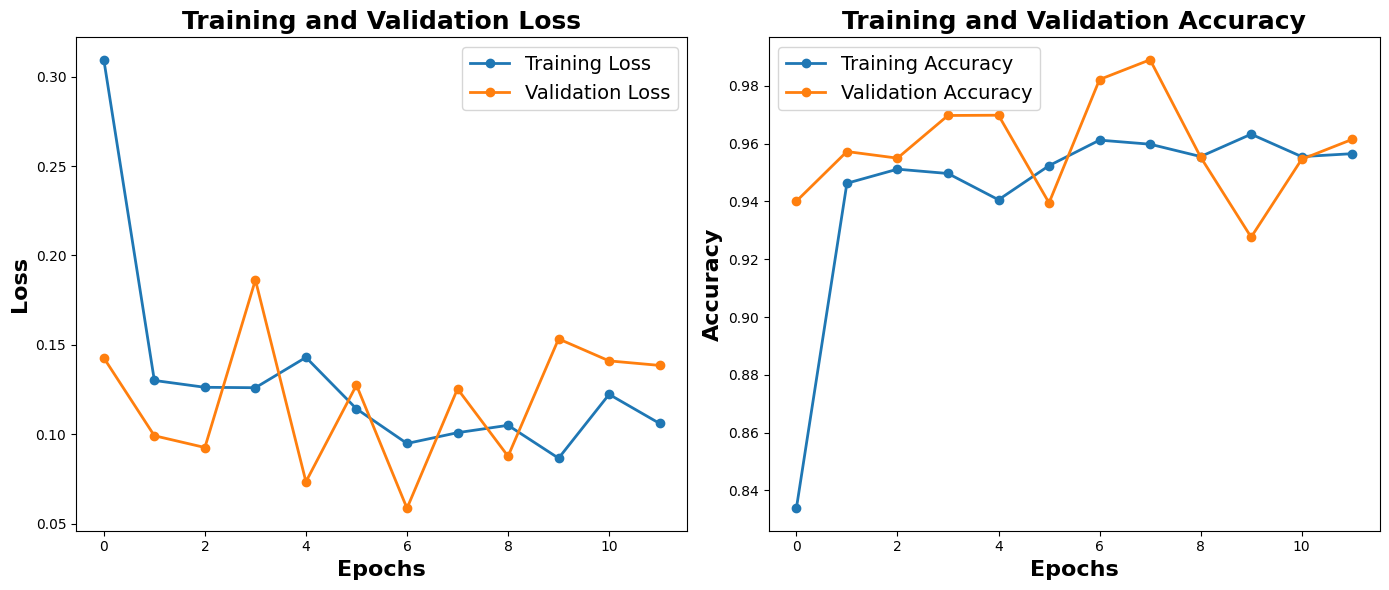

In [6]:
import matplotlib.pyplot as plt

def plot_model_history(history):
    plt.figure(figsize=(14, 6))

    # Plot training and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss', linewidth=2, marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, marker='o')
    plt.title('Training and Validation Loss', fontsize=18, fontweight='bold')
    plt.xlabel('Epochs', fontsize=16, fontweight='bold')
    plt.ylabel('Loss', fontsize=16, fontweight='bold')
    plt.legend(fontsize=14)

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, marker='o')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, marker='o')
    plt.title('Training and Validation Accuracy', fontsize=18, fontweight='bold')
    plt.xlabel('Epochs', fontsize=16, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=16, fontweight='bold')
    plt.legend(fontsize=14)

    plt.tight_layout()
    plt.show()

# Call the function to plot the model history
plot_model_history(history)


In [8]:
import shap

# Create an explainer for your model
explainer = shap.Explainer(model, X_train)

example_data = np.array([[11803, 464, 3288, 2, 2, 585, 2, 524.5]])

example_data_scaled = scaler.transform(example_data)


shap_values = explainer(example_data_scaled)

shap.initjs()
shap.force_plot(shap_values[0])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
